# Full Raw-Text Naive Bayes ABSA (ATE + ACD + ACSA)

This notebook runs an **end-to-end** Multinomial Naive Bayes pipeline where **outer-test inference uses only raw review text** (no gold aspects or categories).

Pipeline:
1. **ATE** — candidate-span classification for explicit aspect terms
2. **Implicit category detection** — multilabel NB on raw text (no span)
3. **ACD** — review-level multilabel aspect-category detection
4. **ACSA** — category + sentiment for extracted / detected aspects
5. **End-to-end** — predicted `(category, sentiment)` tuple micro F1

Oracle diagnostics (gold aspect / gold category) are reported separately and must **not** be confused with raw-text end-to-end scores.

Artifacts: `results/naive_bayes_full/`.

## 0. Environment setup

In [4]:
import sys
from pathlib import Path

SMOKE_TEST = False
N_JOBS = -1
RANDOM_STATE = 42

def setup_paths():
    global REPO_ROOT, ANNOTATIONS_PATH, RESULTS_DIR
    here = Path.cwd()
    if (here / "annotation" / "annotations.json").exists():
        REPO_ROOT = here
    elif (here.parent / "annotation" / "annotations.json").exists():
        REPO_ROOT = here.parent
    else:
        raise FileNotFoundError("Run from project root or notebooks/.")

    ANNOTATIONS_PATH = REPO_ROOT / "annotation" / "annotations.json"
    RESULTS_DIR = REPO_ROOT / "results" / "naive_bayes_full"
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    sys.path.insert(0, str(REPO_ROOT))
    print("REPO_ROOT:", REPO_ROOT)
    print("ANNOTATIONS:", ANNOTATIONS_PATH.exists())
    print("RESULTS_DIR:", RESULTS_DIR)


setup_paths()

REPO_ROOT: /Users/jelenablagojevic/faks/opj/MobilniABSA
ANNOTATIONS: True
RESULTS_DIR: /Users/jelenablagojevic/faks/opj/MobilniABSA/results/naive_bayes_full


In [5]:
import json
import re
import time
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass
from typing import Any, Iterable

try:
    import sklearn
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        f1_score,
        precision_recall_fscore_support,
    )
    from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedGroupKFold
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.naive_bayes import MultinomialNB
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
except ImportError:
    %pip install -q "scikit-learn>=1.5,<2" "pandas>=2" numpy matplotlib
    import sklearn
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        f1_score,
        precision_recall_fscore_support,
    )
    from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedGroupKFold
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.naive_bayes import MultinomialNB
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

print(sklearn.__version__, pd.__version__, np.__version__)

1.7.2 2.3.3 2.3.5


## 1. Model preparation and helper functions

The following cells define the steps for data preparation, feature construction, model fitting, evaluation, and saving intermediate results.

In [6]:
# Shared labels and utility functions
CATEGORIES = [
    "Baterija", "Kamera", "Ekran", "Memorija", "Zvučnici", "Izgled",
    "Hardver", "Softver", "Performanse", "Cena", "Opšta ocena",
]
SENTIMENTS = ["Pozitivan", "Negativan", "Neutralan", "Konflikt"]
POLARITY_ALIASES = {"Konfliktan": "Konflikt"}
RANDOM_STATE = 42


def _normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def _serialize_params(params: dict[str, Any]) -> dict[str, Any]:
    out: dict[str, Any] = {}
    for key, value in params.items():
        if key == "vect":
            out[key] = type(value).__name__
        elif isinstance(value, tuple):
            out[key] = list(value)
        else:
            out[key] = value
    return out


def _per_class_metrics(y_true: np.ndarray, y_pred: np.ndarray, labels: list[str]) -> dict[str, dict]:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    return {
        label: {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1": float(f1[i]),
            "support": int(support[i]),
        }
        for i, label in enumerate(labels)
    }





### Tokenization, features, and helper metrics

This section creates explicit-aspect candidates, constructs text features for ATE, ACD, and ACSA, and defines metrics for spans and label sets.

In [7]:
TOKEN_RE = re.compile(r"\S+")


@dataclass
class FullDatasetSummary:
    n_records_total: int
    n_status_da: int
    n_status_ne: int
    n_status_other: int
    n_valid_comments: int
    n_aspects: int
    n_explicit: int
    n_implicit: int
    n_dropped_empty_da: int
    n_invalid_labels_skipped: int
    n_polarity_normalized: int
    n_span_mismatch: int
    includes_calibration: bool
    category_counts: dict[str, int]
    sentiment_counts: dict[str, int]
    explicit_category_counts: dict[str, int]
    implicit_category_counts: dict[str, int]


def tokenize_with_offsets(text: str) -> list[tuple[int, int, str]]:
    """Return (start, end, token) using original string offsets."""
    return [(m.start(), m.end(), m.group()) for m in TOKEN_RE.finditer(text)]


def generate_candidate_spans(text: str, max_tokens: int = 5) -> list[tuple[int, int, str]]:
    tokens = tokenize_with_offsets(text)
    candidates: list[tuple[int, int, str]] = []
    n = len(tokens)
    for i in range(n):
        for length in range(1, max_tokens + 1):
            j = i + length
            if j > n:
                break
            start = tokens[i][0]
            end = tokens[j - 1][1]
            candidates.append((start, end, text[start:end]))
    return candidates


def span_feature(text: str, start: int, end: int, window: int = 40) -> str:
    left = text[max(0, start - window):start]
    span = text[start:end]
    right = text[end:min(len(text), end + window)]
    return f"[L] {left} [SPAN] {span} [R] {right}"


def category_feature(comment: str, target: str) -> str:
    return f"{comment} [ASPECT] {target}"


def sentiment_feature(category: str, comment: str, target: str) -> str:
    return f"[CATEGORY] {category} {comment} [ASPECT] {target}"


def strict_span_f1(gold: Iterable[tuple[int, int]], pred: Iterable[tuple[int, int]]) -> dict[str, float]:
    gold_set = set(gold)
    pred_set = set(pred)
    tp = len(gold_set & pred_set)
    fp = len(pred_set - gold_set)
    fn = len(gold_set - pred_set)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "precision": float(precision), "recall": float(recall), "f1": float(f1),
        "tp": float(tp), "fp": float(fp), "fn": float(fn),
    }


def tuple_set_f1(true_sets: list[set[str]], pred_sets: list[set[str]]) -> dict[str, float]:
    tp = fp = fn = 0
    for tset, pset in zip(true_sets, pred_sets):
        tp += len(tset & pset)
        fp += len(pset - tset)
        fn += len(tset - pset)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "precision": float(precision), "recall": float(recall), "f1": float(f1),
        "tp": int(tp), "fp": int(fp), "fn": int(fn),
    }


def suppress_overlaps(spans: list[tuple[int, int, float]]) -> list[tuple[int, int, float]]:
    """Greedy non-maximum suppression by score; keep non-overlapping spans."""
    ordered = sorted(spans, key=lambda x: x[2], reverse=True)
    kept: list[tuple[int, int, float]] = []
    for start, end, score in ordered:
        if any(not (end <= ks or start >= ke) for ks, ke, _ in kept):
            continue
        kept.append((start, end, score))
    return sorted(kept, key=lambda x: x[0])

### Loading the dataset

The function loads the annotations, separates reviews and aspects, and records basic statistics and any label irregularities.

In [8]:
def load_full_frames(annotations_path: Path) -> tuple[pd.DataFrame, pd.DataFrame, FullDatasetSummary]:
    """Return (reviews_df, aspects_df, summary)."""
    with annotations_path.open("r", encoding="utf-8-sig") as handle:
        records = json.load(handle)

    review_rows: list[dict[str, Any]] = []
    aspect_rows: list[dict[str, Any]] = []
    dropped_empty = 0
    polarity_normalized = 0
    invalid_labels = 0
    span_mismatch = 0
    n_status_da = n_status_ne = n_status_other = 0
    category_counts: Counter[str] = Counter()
    sentiment_counts: Counter[str] = Counter()
    explicit_category_counts: Counter[str] = Counter()
    implicit_category_counts: Counter[str] = Counter()

    for comment_id, record in enumerate(records):
        status = record.get("review_status")
        if status == "DA":
            n_status_da += 1
        elif status == "NE":
            n_status_ne += 1
            continue
        else:
            n_status_other += 1
            continue

        raw_comment = str(record.get("comment") or "")
        comment = _normalize_whitespace(raw_comment)
        aspect_terms = record.get("aspect_terms") or []
        if not aspect_terms:
            dropped_empty += 1
            continue

        categories: set[str] = set()
        implicit_categories: set[str] = set()
        explicit_spans: list[tuple[int, int, str, str, str]] = []
        pairs: set[str] = set()

        for aspect_idx, aspect in enumerate(aspect_terms):
            category = aspect.get("category")
            polarity = aspect.get("polarity")
            if polarity in POLARITY_ALIASES:
                polarity = POLARITY_ALIASES[polarity]
                polarity_normalized += 1
            if category not in CATEGORIES or polarity not in SENTIMENTS:
                invalid_labels += 1
                continue

            fr = aspect.get("fr", -1)
            to = aspect.get("to", -1)
            target = aspect.get("trg")
            is_implicit = fr == -1 or to == -1 or target in (None, "", "NULL")

            if is_implicit:
                target_text = "[IMPLICIT]"
                start = end = -1
                implicit_categories.add(category)
                implicit_category_counts[category] += 1
            else:
                start, end = int(fr), int(to)
                target_text = _normalize_whitespace(str(target))
                try:
                    sliced = raw_comment[start:end]
                    if _normalize_whitespace(sliced) != target_text:
                        span_mismatch += 1
                except Exception:
                    span_mismatch += 1
                explicit_spans.append((start, end, target_text, category, polarity))
                explicit_category_counts[category] += 1

            categories.add(category)
            category_counts[category] += 1
            sentiment_counts[polarity] += 1
            pairs.add(f"{category}|||{polarity}")
            aspect_rows.append({
                "comment_id": comment_id,
                "aspect_id": f"{comment_id}:{aspect_idx}",
                "phone": record.get("phone"),
                "comment": comment,
                "raw_comment": raw_comment,
                "fr": start,
                "to": end,
                "target": None if is_implicit else target_text,
                "is_implicit": is_implicit,
                "category": category,
                "sentiment": polarity,
                "text_category": category_feature(comment, target_text),
                "text_sentiment": sentiment_feature(category, comment, target_text),
            })

        if not categories:
            continue
        review_rows.append({
            "comment_id": comment_id,
            "phone": record.get("phone"),
            "comment": comment,
            "raw_comment": raw_comment,
            "categories": sorted(categories),
            "implicit_categories": sorted(implicit_categories),
            "explicit_spans": explicit_spans,
            "gold_pairs": sorted(pairs),
        })

    reviews = pd.DataFrame(review_rows)
    aspects = pd.DataFrame(aspect_rows)
    summary = FullDatasetSummary(
        n_records_total=len(records),
        n_status_da=n_status_da,
        n_status_ne=n_status_ne,
        n_status_other=n_status_other,
        n_valid_comments=int(len(reviews)),
        n_aspects=int(len(aspects)),
        n_explicit=int((~aspects["is_implicit"]).sum()) if len(aspects) else 0,
        n_implicit=int(aspects["is_implicit"].sum()) if len(aspects) else 0,
        n_dropped_empty_da=dropped_empty,
        n_invalid_labels_skipped=invalid_labels,
        n_polarity_normalized=polarity_normalized,
        n_span_mismatch=span_mismatch,
        includes_calibration=True,
        category_counts=dict(category_counts),
        sentiment_counts=dict(sentiment_counts),
        explicit_category_counts=dict(explicit_category_counts),
        implicit_category_counts=dict(implicit_category_counts),
    )
    return reviews, aspects, summary

### Pipelines and hyperparameter grid

This section defines the text-processing pipelines and the values evaluated by the inner search for the NB models.

In [9]:
def _param_grid(smoke: bool) -> list[dict[str, Any]]:
    if smoke:
        return [{
            "vect": [CountVectorizer(), TfidfVectorizer()],
            "vect__lowercase": [True],
            "vect__ngram_range": [(1, 1), (1, 2)],
            "vect__min_df": [2],
            "clf__alpha": [0.5, 1.0],
            "clf__fit_prior": [True],
        }]
    return [{
        "vect": [CountVectorizer(), TfidfVectorizer()],
        "vect__lowercase": [True, False],
        "vect__ngram_range": [(1, 1), (1, 2)],
        "vect__min_df": [2],
        "clf__alpha": [0.1, 0.5, 1.0],
        "clf__fit_prior": [True, False],
    }]


def _make_text_pipeline() -> Pipeline:
    return Pipeline([("vect", CountVectorizer()), ("clf", MultinomialNB())])


def _make_multilabel_pipeline() -> Pipeline:
    return Pipeline([
        ("vect", CountVectorizer()),
        ("clf", OneVsRestClassifier(MultinomialNB(), n_jobs=1)),
    ])


def _param_grid_multilabel(smoke: bool) -> list[dict[str, Any]]:
    if smoke:
        return [{
            "vect": [CountVectorizer(), TfidfVectorizer()],
            "vect__lowercase": [True],
            "vect__ngram_range": [(1, 1), (1, 2)],
            "vect__min_df": [2],
            "clf__estimator__alpha": [0.5, 1.0],
            "clf__estimator__fit_prior": [True],
        }]
    return [{
        "vect": [CountVectorizer(), TfidfVectorizer()],
        "vect__lowercase": [True, False],
        "vect__ngram_range": [(1, 1), (1, 2)],
        "vect__min_df": [2],
        "clf__estimator__alpha": [0.1, 0.5, 1.0],
        "clf__estimator__fit_prior": [True, False],
    }]

### Preparing and fitting the ATE and NB models

Positive and negative ATE candidates are created first. Grouped cross-validation is then used to tune the binary, multiclass, and multilabel NB models.

In [10]:
def build_ate_training_rows(
    reviews: pd.DataFrame,
    max_tokens: int = 5,
    negatives_per_positive: int = 5,
    window: int = 40,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rng = np.random.RandomState(random_state)
    rows: list[dict[str, Any]] = []
    for _, rev in reviews.iterrows():
        text = rev["raw_comment"]
        gold = {(int(s), int(e)) for s, e, *_ in rev["explicit_spans"]}
        candidates = generate_candidate_spans(text, max_tokens=max_tokens)
        for s, e, trg, *_ in rev["explicit_spans"]:
            if (s, e) not in {(c[0], c[1]) for c in candidates}:
                candidates.append((s, e, trg))
        positives = [c for c in candidates if (c[0], c[1]) in gold]
        negatives = [c for c in candidates if (c[0], c[1]) not in gold]
        if not positives:
            continue
        n_neg = min(len(negatives), negatives_per_positive * len(positives))
        if n_neg > 0:
            chosen_idx = rng.choice(len(negatives), size=n_neg, replace=False)
            chosen_neg = [negatives[i] for i in chosen_idx]
        else:
            chosen_neg = []
        for start, end, span_text in positives + chosen_neg:
            rows.append({
                "comment_id": int(rev["comment_id"]),
                "fr": int(start),
                "to": int(end),
                "span_text": span_text,
                "feature": span_feature(text, start, end, window=window),
                "label": 1 if (start, end) in gold else 0,
            })
    return pd.DataFrame(rows)


def fit_binary_nb(texts, y, groups, smoke, n_jobs, random_state, n_inner) -> GridSearchCV:
    unique_groups = np.unique(groups)
    actual_inner = max(2, min(n_inner, len(unique_groups)))
    try:
        y_bin = y.astype(int)
        if len(np.unique(y_bin)) < 2:
            raise ValueError("single class")
        cv: Any = StratifiedGroupKFold(
            n_splits=actual_inner, shuffle=True, random_state=random_state
        )
        next(cv.split(texts, y_bin, groups))
    except Exception:
        cv = GroupKFold(n_splits=min(actual_inner, len(unique_groups)))
    search = GridSearchCV(
        estimator=_make_text_pipeline(), param_grid=_param_grid(smoke), scoring="f1",
        cv=cv, n_jobs=n_jobs, refit=True, verbose=0,
    )
    search.fit(texts, y.astype(int), groups=groups)
    return search


def fit_multiclass_nb(texts, y, groups, smoke, n_jobs, random_state, n_inner) -> GridSearchCV:
    unique_groups = np.unique(groups)
    actual_inner = max(2, min(n_inner, len(unique_groups)))
    try:
        cv: Any = StratifiedGroupKFold(
            n_splits=actual_inner, shuffle=True, random_state=random_state
        )
        next(cv.split(texts, y, groups))
    except Exception:
        cv = GroupKFold(n_splits=min(actual_inner, len(unique_groups)))
    search = GridSearchCV(
        estimator=_make_text_pipeline(), param_grid=_param_grid(smoke), scoring="f1_macro",
        cv=cv, n_jobs=n_jobs, refit=True, verbose=0,
    )
    search.fit(texts, y, groups=groups)
    return search


def fit_multilabel_nb(texts, y, groups, smoke, n_jobs, n_inner) -> GridSearchCV:
    unique_groups = np.unique(groups)
    actual_inner = max(2, min(n_inner, len(unique_groups)))
    cv = GroupKFold(n_splits=actual_inner)
    search = GridSearchCV(
        estimator=_make_multilabel_pipeline(), param_grid=_param_grid_multilabel(smoke),
        scoring="f1_macro", cv=cv, n_jobs=n_jobs, refit=True, verbose=0,
    )
    search.fit(texts, y, groups=groups)
    return search

### Prediction and evaluation

These functions extract ATE spans, select a threshold on a subset of the training data, and compute multilabel classification metrics.

In [11]:
def predict_ate_spans(
    model: Any, text: str, max_tokens: int = 5, window: int = 40, threshold: float = 0.5,
) -> list[tuple[int, int, str, float]]:
    candidates = generate_candidate_spans(text, max_tokens=max_tokens)
    if not candidates:
        return []
    features = np.array([span_feature(text, s, e, window=window) for s, e, _ in candidates])
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(features)[:, 1]
    else:
        scores = model.predict(features).astype(float)
    scored = [
        (s, e, float(score))
        for (s, e, _), score in zip(candidates, scores)
        if float(score) >= threshold
    ]
    kept = suppress_overlaps(scored)
    return [(s, e, text[s:e], score) for s, e, score in kept]


def choose_ate_threshold(
    model: Any,
    reviews: pd.DataFrame,
    max_tokens: int,
    window: int,
    thresholds: list[float] | None = None,
) -> float:
    thresholds = thresholds or [0.3, 0.4, 0.5, 0.6, 0.7]
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        gold_all: list[tuple[int, int]] = []
        pred_all: list[tuple[int, int]] = []
        for _, rev in reviews.iterrows():
            gold = [(int(s), int(e)) for s, e, *_ in rev["explicit_spans"]]
            preds = predict_ate_spans(
                model, rev["raw_comment"], max_tokens=max_tokens, window=window, threshold=t
            )
            gold_all.extend(gold)
            pred_all.extend([(s, e) for s, e, _, _ in preds])
        metrics = strict_span_f1(gold_all, pred_all)
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_t = t
    return best_t


def multilabel_metrics(y_true: np.ndarray, y_pred: np.ndarray, labels: list[str]) -> dict[str, Any]:
    per_class: dict[str, dict[str, float]] = {}
    for i, label in enumerate(labels):
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true[:, i], y_pred[:, i], average="binary", zero_division=0
        )
        per_class[label] = {
            "precision": float(precision), "recall": float(recall),
            "f1": float(f1), "support": int(y_true[:, i].sum()),
        }
    return {
        "micro_f1": float(f1_score(y_true, y_pred, average="micro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "samples_f1": float(f1_score(y_true, y_pred, average="samples", zero_division=0)),
        "per_class": per_class,
    }

### Saving intermediate results

The helper functions save the result of each outer fold and allow a long experiment to resume from the last completed step.

In [12]:
def _checkpoint_dir(results_dir: Path) -> Path:
    path = results_dir / "checkpoints"
    path.mkdir(parents=True, exist_ok=True)
    return path


def _fold_checkpoint_path(results_dir: Path, fold_idx: int) -> Path:
    return _checkpoint_dir(results_dir) / f"fold_{fold_idx:02d}.json"


def _save_fold_checkpoint(results_dir: Path, fold_idx: int, payload: dict[str, Any]) -> None:
    path = _fold_checkpoint_path(results_dir, fold_idx)
    tmp = path.with_suffix(".tmp")
    with tmp.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, ensure_ascii=False, indent=2)
    tmp.replace(path)
    progress_path = _checkpoint_dir(results_dir) / "progress.json"
    completed = sorted(
        int(p.stem.rsplit("_", 1)[1])
        for p in _checkpoint_dir(results_dir).glob("fold_[0-9][0-9].json")
    )
    with progress_path.open("w", encoding="utf-8") as handle:
        json.dump({
            "completed_folds": completed,
            "latest_fold": fold_idx,
            "latest_metrics": {
                "ate_f1": payload["fold_row"]["ate_f1"],
                "acd_macro_f1": payload["fold_row"]["acd_macro_f1"],
                "e2e_pair_f1": payload["fold_row"]["e2e_pair_f1"],
            },
        }, handle, ensure_ascii=False, indent=2)
    print(f"[checkpoint] saved fold {fold_idx} -> {path}", flush=True)


def _load_fold_checkpoint(results_dir: Path, fold_idx: int) -> dict[str, Any] | None:
    path = _fold_checkpoint_path(results_dir, fold_idx)
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)

### Main experiment function

The `run_full_experiment` function connects data preparation, outer and inner splits, fitting of all system components, and separate calculation of oracle diagnostics and end-to-end results.

In [13]:
def run_full_experiment(
    annotations_path: Path,
    results_dir: Path,
    smoke: bool = False,
    n_jobs: int = -1,
    random_state: int = RANDOM_STATE,
    max_tokens: int = 5,
    negatives_per_positive: int = 5,
    window: int = 40,
    resume: bool = True,
) -> dict[str, Any]:
    results_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    reviews, aspects, summary = load_full_frames(annotations_path)
    n_outer = 2 if smoke else 10
    n_inner = 2 if smoke else 3
    print(
        f"Loaded {summary.n_valid_comments} reviews / {summary.n_aspects} aspects "
        f"(explicit={summary.n_explicit}, implicit={summary.n_implicit})", flush=True,
    )
    print(
        f"Outer={n_outer}, inner={n_inner}, smoke={smoke}, random_state={random_state}, resume={resume}",
        flush=True,
    )

    mlb_acd = MultiLabelBinarizer(classes=CATEGORIES)
    y_acd = mlb_acd.fit_transform(reviews["categories"])
    mlb_impl = MultiLabelBinarizer(classes=CATEGORIES)
    y_impl = mlb_impl.fit_transform(reviews["implicit_categories"])
    majority_label = [
        Counter(cats).most_common(1)[0][0] if cats else "Opšta ocena"
        for cats in reviews["categories"]
    ]
    majority_enc = LabelEncoder().fit(CATEGORIES)
    y_majority = majority_enc.transform(majority_label)
    groups = reviews["comment_id"].to_numpy()
    texts = reviews["comment"].astype(str).to_numpy()
    outer = StratifiedGroupKFold(n_splits=n_outer, shuffle=True, random_state=random_state)

    fold_rows = []
    ate_pred_rows = []
    acd_true_all, acd_pred_all = [], []
    impl_true_all, impl_pred_all = [], []
    e2e_true_sets, e2e_pred_sets = [], []
    oracle_cat_true, oracle_cat_pred = [], []
    oracle_sent_true, oracle_sent_pred = [], []
    chained_sent_true, chained_sent_pred = [], []
    e2e_pair_rows = []
    chosen_params: dict[str, list] = defaultdict(list)
    cat_encoder = LabelEncoder().fit(CATEGORIES)
    sent_encoder = LabelEncoder().fit(SENTIMENTS)

    for fold_idx, (train_idx, test_idx) in enumerate(
        outer.split(texts, y_majority, groups), start=1
    ):
        cached = _load_fold_checkpoint(results_dir, fold_idx) if resume and not smoke else None
        if cached is not None:
            print(f"[full] fold {fold_idx}/{n_outer} loaded from checkpoint", flush=True)
            fold_rows.append(cached["fold_row"])
            ate_pred_rows.extend(cached["ate_pred_rows"])
            acd_true_all.append(np.array(cached["acd_true"]))
            acd_pred_all.append(np.array(cached["acd_pred"]))
            impl_true_all.append(np.array(cached["impl_true"]))
            impl_pred_all.append(np.array(cached["impl_pred"]))
            e2e_true_sets.extend(set(x) for x in cached["e2e_true_sets"])
            e2e_pred_sets.extend(set(x) for x in cached["e2e_pred_sets"])
            oracle_cat_true.extend(cached["oracle_cat_true"])
            oracle_cat_pred.extend(cached["oracle_cat_pred"])
            oracle_sent_true.extend(cached["oracle_sent_true"])
            oracle_sent_pred.extend(cached["oracle_sent_pred"])
            chained_sent_true.extend(cached["chained_sent_true"])
            chained_sent_pred.extend(cached["chained_sent_pred"])
            e2e_pair_rows.extend(cached["e2e_pair_rows"])
            for key, values in cached.get("chosen_params", {}).items():
                chosen_params[key].extend(values)
            continue

        print(f"[full] fold {fold_idx}/{n_outer} ...", flush=True)
        train_reviews = reviews.iloc[train_idx].reset_index(drop=True)
        test_reviews = reviews.iloc[test_idx].reset_index(drop=True)
        train_ids = set(train_reviews["comment_id"].tolist())
        train_aspects = aspects[aspects["comment_id"].isin(train_ids)].reset_index(drop=True)
        test_aspects = aspects[
            aspects["comment_id"].isin(set(test_reviews["comment_id"]))
        ].reset_index(drop=True)

        fold_oracle_cat_true, fold_oracle_cat_pred = [], []
        fold_oracle_sent_true, fold_oracle_sent_pred = [], []
        fold_chained_sent_true, fold_chained_sent_pred = [], []
        fold_ate_pred_rows, fold_e2e_pair_rows = [], []
        fold_chosen: dict[str, list] = defaultdict(list)

        ate_train = build_ate_training_rows(
            train_reviews, max_tokens=max_tokens,
            negatives_per_positive=negatives_per_positive,
            window=window, random_state=random_state + fold_idx,
        )
        ate_search = fit_binary_nb(
            ate_train["feature"].astype(str).to_numpy(), ate_train["label"].to_numpy(),
            ate_train["comment_id"].to_numpy(), smoke=smoke, n_jobs=n_jobs,
            random_state=random_state, n_inner=n_inner,
        )
        fold_chosen["ate"].append({
            "fold": fold_idx, "params": _serialize_params(ate_search.best_params_)
        })
        tune_reviews = train_reviews.sample(
            n=min(len(train_reviews), 400 if not smoke else 80),
            random_state=random_state + fold_idx,
        )
        threshold = choose_ate_threshold(
            ate_search.best_estimator_, tune_reviews, max_tokens=max_tokens, window=window
        )
        gold_spans, pred_spans = [], []
        pred_spans_by_comment = {}
        for _, rev in test_reviews.iterrows():
            g = [(int(s), int(e)) for s, e, *_ in rev["explicit_spans"]]
            p = predict_ate_spans(
                ate_search.best_estimator_, rev["raw_comment"], max_tokens=max_tokens,
                window=window, threshold=threshold,
            )
            gold_spans.extend(g)
            pred_spans.extend([(s, e) for s, e, _, _ in p])
            pred_spans_by_comment[int(rev["comment_id"])] = p
            for s, e, trg, score in p:
                fold_ate_pred_rows.append({
                    "fold": fold_idx, "comment_id": int(rev["comment_id"]),
                    "fr": s, "to": e, "span_text": trg, "score": score,
                    "exact_match": (s, e) in set(g),
                })
        ate_fold = strict_span_f1(gold_spans, pred_spans)
        ate_fold["threshold"] = threshold

        acd_search = fit_multilabel_nb(
            train_reviews["comment"].astype(str).to_numpy(), y_acd[train_idx],
            train_reviews["comment_id"].to_numpy(), smoke=smoke,
            n_jobs=n_jobs, n_inner=n_inner,
        )
        fold_chosen["acd"].append({
            "fold": fold_idx, "params": _serialize_params(acd_search.best_params_)
        })
        acd_pred = acd_search.predict(test_reviews["comment"].astype(str).to_numpy())
        acd_true = y_acd[test_idx]
        acd_fold = multilabel_metrics(acd_true, acd_pred, CATEGORIES)

        if y_impl[train_idx].sum() > 0:
            impl_search = fit_multilabel_nb(
                train_reviews["comment"].astype(str).to_numpy(), y_impl[train_idx],
                train_reviews["comment_id"].to_numpy(), smoke=smoke,
                n_jobs=n_jobs, n_inner=n_inner,
            )
            fold_chosen["implicit"].append({
                "fold": fold_idx, "params": _serialize_params(impl_search.best_params_)
            })
            impl_pred = impl_search.predict(test_reviews["comment"].astype(str).to_numpy())
        else:
            impl_pred = np.zeros_like(y_impl[test_idx])
            fold_chosen["implicit"].append({"fold": fold_idx, "params": {}})
        impl_true = y_impl[test_idx]
        impl_fold = multilabel_metrics(impl_true, impl_pred, CATEGORIES)

        cat_search = fit_multiclass_nb(
            train_aspects["text_category"].astype(str).to_numpy(),
            cat_encoder.transform(train_aspects["category"].astype(str)),
            train_aspects["comment_id"].to_numpy(), smoke=smoke, n_jobs=n_jobs,
            random_state=random_state, n_inner=n_inner,
        )
        fold_chosen["category"].append({
            "fold": fold_idx, "params": _serialize_params(cat_search.best_params_)
        })
        sent_search = fit_multiclass_nb(
            train_aspects["text_sentiment"].astype(str).to_numpy(),
            sent_encoder.transform(train_aspects["sentiment"].astype(str)),
            train_aspects["comment_id"].to_numpy(), smoke=smoke, n_jobs=n_jobs,
            random_state=random_state, n_inner=n_inner,
        )
        fold_chosen["sentiment"].append({
            "fold": fold_idx, "params": _serialize_params(sent_search.best_params_)
        })

        if len(test_aspects):
            o_cat = cat_encoder.inverse_transform(
                cat_search.predict(test_aspects["text_category"].astype(str).to_numpy())
            )
            o_sent = sent_encoder.inverse_transform(
                sent_search.predict(test_aspects["text_sentiment"].astype(str).to_numpy())
            )
            chained_texts = [
                sentiment_feature(
                    pred_c, row["comment"],
                    "[IMPLICIT]" if row["is_implicit"] else str(row["target"]),
                )
                for pred_c, (_, row) in zip(o_cat, test_aspects.iterrows())
            ]
            c_sent = sent_encoder.inverse_transform(sent_search.predict(np.array(chained_texts)))
            fold_oracle_cat_true.extend(test_aspects["category"].astype(str).tolist())
            fold_oracle_cat_pred.extend(o_cat.tolist())
            fold_oracle_sent_true.extend(test_aspects["sentiment"].astype(str).tolist())
            fold_oracle_sent_pred.extend(o_sent.tolist())
            fold_chained_sent_true.extend(test_aspects["sentiment"].astype(str).tolist())
            fold_chained_sent_pred.extend(c_sent.tolist())

        fold_true_sets, fold_pred_sets = [], []
        for local_i, (_, rev) in enumerate(test_reviews.iterrows()):
            true_set = set(rev["gold_pairs"])
            pred_set: set[str] = set()
            for s, e, trg, score in pred_spans_by_comment.get(int(rev["comment_id"]), []):
                feat_cat = category_feature(rev["comment"], _normalize_whitespace(trg))
                pred_cat = cat_encoder.inverse_transform(cat_search.predict([feat_cat]))[0]
                feat_sent = sentiment_feature(
                    pred_cat, rev["comment"], _normalize_whitespace(trg)
                )
                pred_sent = sent_encoder.inverse_transform(sent_search.predict([feat_sent]))[0]
                pred_set.add(f"{pred_cat}|||{pred_sent}")
            for j, present in enumerate(impl_pred[local_i]):
                if not present:
                    continue
                pred_cat = CATEGORIES[j]
                feat_sent = sentiment_feature(pred_cat, rev["comment"], "[IMPLICIT]")
                pred_sent = sent_encoder.inverse_transform(sent_search.predict([feat_sent]))[0]
                pred_set.add(f"{pred_cat}|||{pred_sent}")
            fold_true_sets.append(true_set)
            fold_pred_sets.append(pred_set)
            fold_e2e_pair_rows.append({
                "fold": fold_idx, "comment_id": int(rev["comment_id"]),
                "true_pairs": sorted(true_set), "pred_pairs": sorted(pred_set),
                "exact_set_match": true_set == pred_set,
            })

        e2e_fold = tuple_set_f1(fold_true_sets, fold_pred_sets)
        fold_row = {
            "fold": fold_idx,
            "ate_precision": ate_fold["precision"], "ate_recall": ate_fold["recall"],
            "ate_f1": ate_fold["f1"], "ate_threshold": threshold,
            "acd_micro_f1": acd_fold["micro_f1"], "acd_macro_f1": acd_fold["macro_f1"],
            "implicit_micro_f1": impl_fold["micro_f1"],
            "implicit_macro_f1": impl_fold["macro_f1"],
            "e2e_pair_precision": e2e_fold["precision"],
            "e2e_pair_recall": e2e_fold["recall"], "e2e_pair_f1": e2e_fold["f1"],
            "n_test_reviews": int(len(test_reviews)),
        }
        payload = {
            "fold_row": fold_row, "ate_pred_rows": fold_ate_pred_rows,
            "acd_true": acd_true.tolist(), "acd_pred": np.asarray(acd_pred).tolist(),
            "impl_true": impl_true.tolist(), "impl_pred": np.asarray(impl_pred).tolist(),
            "e2e_true_sets": [sorted(s) for s in fold_true_sets],
            "e2e_pred_sets": [sorted(s) for s in fold_pred_sets],
            "oracle_cat_true": fold_oracle_cat_true, "oracle_cat_pred": fold_oracle_cat_pred,
            "oracle_sent_true": fold_oracle_sent_true, "oracle_sent_pred": fold_oracle_sent_pred,
            "chained_sent_true": fold_chained_sent_true,
            "chained_sent_pred": fold_chained_sent_pred,
            "e2e_pair_rows": fold_e2e_pair_rows, "chosen_params": dict(fold_chosen),
        }
        if not smoke:
            _save_fold_checkpoint(results_dir, fold_idx, payload)

        fold_rows.append(fold_row)
        ate_pred_rows.extend(fold_ate_pred_rows)
        acd_true_all.append(acd_true)
        acd_pred_all.append(acd_pred)
        impl_true_all.append(impl_true)
        impl_pred_all.append(impl_pred)
        e2e_true_sets.extend(fold_true_sets)
        e2e_pred_sets.extend(fold_pred_sets)
        oracle_cat_true.extend(fold_oracle_cat_true)
        oracle_cat_pred.extend(fold_oracle_cat_pred)
        oracle_sent_true.extend(fold_oracle_sent_true)
        oracle_sent_pred.extend(fold_oracle_sent_pred)
        chained_sent_true.extend(fold_chained_sent_true)
        chained_sent_pred.extend(fold_chained_sent_pred)
        e2e_pair_rows.extend(fold_e2e_pair_rows)
        for key, values in fold_chosen.items():
            chosen_params[key].extend(values)
        print(
            f"[full] fold {fold_idx}: ate_f1={ate_fold['f1']:.4f} "
            f"acd_macro={acd_fold['macro_f1']:.4f} e2e_f1={e2e_fold['f1']:.4f}", flush=True,
        )

    folds_df = pd.DataFrame(fold_rows)
    acd_true_mat, acd_pred_mat = np.vstack(acd_true_all), np.vstack(acd_pred_all)
    impl_true_mat, impl_pred_mat = np.vstack(impl_true_all), np.vstack(impl_pred_all)
    package: dict[str, Any] = {
        "random_state": random_state, "smoke": smoke,
        "annotations_path": str(annotations_path), "runtime_seconds": float(time.time() - t0),
        "config": {
            "n_outer": n_outer, "n_inner": n_inner, "max_tokens": max_tokens,
            "negatives_per_positive": negatives_per_positive, "window": window, "resume": resume,
        },
        "dataset_summary": asdict(summary), "folds": fold_rows,
        "aggregate": {
            "ate_f1_mean": float(folds_df["ate_f1"].mean()),
            "ate_f1_std": float(folds_df["ate_f1"].std(ddof=0)),
            "ate_precision_mean": float(folds_df["ate_precision"].mean()),
            "ate_recall_mean": float(folds_df["ate_recall"].mean()),
            "acd_macro_f1_mean": float(folds_df["acd_macro_f1"].mean()),
            "acd_macro_f1_std": float(folds_df["acd_macro_f1"].std(ddof=0)),
            "acd_micro_f1_mean": float(folds_df["acd_micro_f1"].mean()),
            "implicit_macro_f1_mean": float(folds_df["implicit_macro_f1"].mean()),
            "implicit_micro_f1_mean": float(folds_df["implicit_micro_f1"].mean()),
            "e2e_pair_f1_mean": float(folds_df["e2e_pair_f1"].mean()),
            "e2e_pair_f1_std": float(folds_df["e2e_pair_f1"].std(ddof=0)),
            "e2e_pair_precision_mean": float(folds_df["e2e_pair_precision"].mean()),
            "e2e_pair_recall_mean": float(folds_df["e2e_pair_recall"].mean()),
        },
        "ate": {
            "pooled": strict_span_f1([], []),
            "fold_mean_f1": float(folds_df["ate_f1"].mean()),
            "description": "Candidate-span MultinomialNB; strict (fr,to) F1; implicit excluded",
        },
        "acd": {
            "pooled": multilabel_metrics(acd_true_mat, acd_pred_mat, CATEGORIES),
            "description": "Review-level multilabel category detection from raw text",
        },
        "implicit_detection": {
            "pooled": multilabel_metrics(impl_true_mat, impl_pred_mat, CATEGORIES),
            "description": "Review-level multilabel implicit category detection from raw text",
        },
        "oracle_category": {
            "evaluation_mode": "gold_aspect",
            "aggregate": {
                "pooled_accuracy": float(accuracy_score(oracle_cat_true, oracle_cat_pred)) if oracle_cat_true else 0.0,
                "pooled_macro_f1": float(f1_score(
                    oracle_cat_true, oracle_cat_pred, average="macro",
                    labels=CATEGORIES, zero_division=0,
                )) if oracle_cat_true else 0.0,
            },
            "classification_report": classification_report(
                oracle_cat_true, oracle_cat_pred, labels=CATEGORIES, digits=4, zero_division=0
            ) if oracle_cat_true else "",
            "per_class": _per_class_metrics(
                np.array(oracle_cat_true), np.array(oracle_cat_pred), CATEGORIES
            ) if oracle_cat_true else {},
        },
        "oracle_sentiment": {
            "evaluation_mode": "oracle_gold_category_gold_aspect",
            "aggregate": {
                "pooled_accuracy": float(accuracy_score(oracle_sent_true, oracle_sent_pred)) if oracle_sent_true else 0.0,
                "pooled_macro_f1": float(f1_score(
                    oracle_sent_true, oracle_sent_pred, average="macro",
                    labels=SENTIMENTS, zero_division=0,
                )) if oracle_sent_true else 0.0,
            },
            "classification_report": classification_report(
                oracle_sent_true, oracle_sent_pred, labels=SENTIMENTS, digits=4, zero_division=0
            ) if oracle_sent_true else "",
        },
        "chained_sentiment": {
            "evaluation_mode": "chained_predicted_category_gold_aspect",
            "aggregate": {
                "pooled_accuracy": float(accuracy_score(chained_sent_true, chained_sent_pred)) if chained_sent_true else 0.0,
                "pooled_macro_f1": float(f1_score(
                    chained_sent_true, chained_sent_pred, average="macro",
                    labels=SENTIMENTS, zero_division=0,
                )) if chained_sent_true else 0.0,
            },
            "classification_report": classification_report(
                chained_sent_true, chained_sent_pred, labels=SENTIMENTS, digits=4, zero_division=0
            ) if chained_sent_true else "",
        },
        "end_to_end": {
            "description": "Raw text only: ATE spans + implicit detector → category → sentiment; tuple micro F1",
            "pooled": tuple_set_f1(e2e_true_sets, e2e_pred_sets),
            "set_exact_match_rate": float(np.mean([
                t == p for t, p in zip(e2e_true_sets, e2e_pred_sets)
            ])) if e2e_true_sets else 0.0,
        },
        "chosen_params": dict(chosen_params),
        "library_versions": {
            "numpy": np.__version__, "pandas": pd.__version__,
            "sklearn": __import__("sklearn").__version__,
        },
    }
    package["ate"]["pooled_fold_means"] = {
        "precision": float(folds_df["ate_precision"].mean()),
        "recall": float(folds_df["ate_recall"].mean()),
        "f1": float(folds_df["ate_f1"].mean()),
    }
    metrics_path = results_dir / "metrics.json"
    with metrics_path.open("w", encoding="utf-8") as handle:
        json.dump(package, handle, ensure_ascii=False, indent=2)
    folds_df.to_csv(results_dir / "folds.csv", index=False, encoding="utf-8")
    pd.DataFrame(ate_pred_rows).to_csv(
        results_dir / "ate_predictions.csv", index=False, encoding="utf-8"
    )
    pd.DataFrame(e2e_pair_rows).to_csv(
        results_dir / "e2e_pair_predictions.csv", index=False, encoding="utf-8"
    )
    errors = [row for row in e2e_pair_rows if not row["exact_set_match"]][:20]
    with (results_dir / "error_examples.json").open("w", encoding="utf-8") as handle:
        json.dump(errors, handle, ensure_ascii=False, indent=2)
    print(f"Saved metrics -> {metrics_path}")
    print(f"Runtime: {package['runtime_seconds']:.1f}s")
    return package

## 2. Dataset overview

Explicit spans (`fr`/`to`/`trg`) are used to fit the ATE model. Implicit aspects (`fr=-1`) are handled by a separate multilabel classifier.

In [14]:
from IPython.display import display

reviews, aspects, summary = load_full_frames(ANNOTATIONS_PATH)
print(summary)
print("\nCategory counts:")
display(pd.Series(summary.category_counts).sort_values(ascending=False).to_frame("count"))
print("Implicit category counts:")
display(pd.Series(summary.implicit_category_counts).sort_values(ascending=False).to_frame("count"))
display(reviews.head(2))
display(aspects.head(3))

FullDatasetSummary(n_records_total=17551, n_status_da=6491, n_status_ne=11060, n_status_other=0, n_valid_comments=6480, n_aspects=18793, n_explicit=15286, n_implicit=3507, n_dropped_empty_da=11, n_invalid_labels_skipped=0, n_polarity_normalized=0, n_span_mismatch=0, includes_calibration=True, category_counts={'Opšta ocena': 3723, 'Izgled': 1143, 'Softver': 2774, 'Ekran': 1232, 'Kamera': 2248, 'Baterija': 2716, 'Cena': 976, 'Hardver': 1766, 'Performanse': 1358, 'Zvučnici': 667, 'Memorija': 190}, sentiment_counts={'Pozitivan': 10038, 'Negativan': 7878, 'Neutralan': 702, 'Konflikt': 175}, explicit_category_counts={'Opšta ocena': 2704, 'Izgled': 731, 'Softver': 2487, 'Ekran': 1210, 'Kamera': 2223, 'Baterija': 2575, 'Cena': 768, 'Hardver': 1293, 'Zvučnici': 624, 'Memorija': 189, 'Performanse': 482}, implicit_category_counts={'Cena': 208, 'Opšta ocena': 1019, 'Hardver': 473, 'Izgled': 412, 'Softver': 287, 'Performanse': 876, 'Zvučnici': 43, 'Baterija': 141, 'Kamera': 25, 'Ekran': 22, 'Memori

,count
Opšta ocena,3723
Softver,2774
Baterija,2716
Kamera,2248
Hardver,1766
Performanse,1358
Ekran,1232
Izgled,1143
Cena,976
Zvučnici,667


Implicit category counts:


,count
Opšta ocena,1019
Performanse,876
Hardver,473
Izgled,412
Softver,287
Cena,208
Baterija,141
Zvučnici,43
Kamera,25
Ekran,22


,comment_id,phone,comment,raw_comment,categories,implicit_categories,explicit_spans,gold_pairs
0,1,Huawei P50 Pro,"Najkonkretnije me zanima, da li na huawei tele...","Najkonkretnije me zanima, da li na huawei tele...","[Izgled, Opšta ocena]",[],"[(386, 394, kvalitet, Opšta ocena, Pozitivan),...","[Izgled|||Pozitivan, Opšta ocena|||Pozitivan]"
1,2,Huawei P50 Pro,Huawei je brend kvalitet i sve napravljeno da ...,Huawei je brend kvalitet i sve napravljeno da ...,[Izgled],[],"[(16, 24, kvalitet, Izgled, Pozitivan)]",[Izgled|||Pozitivan]


,comment_id,aspect_id,phone,comment,raw_comment,fr,to,target,is_implicit,category,sentiment,text_category,text_sentiment
0,1,1:0,Huawei P50 Pro,"Najkonkretnije me zanima, da li na huawei tele...","Najkonkretnije me zanima, da li na huawei tele...",386,394,kvalitet,False,Opšta ocena,Pozitivan,"Najkonkretnije me zanima, da li na huawei tele...",[CATEGORY] Opšta ocena Najkonkretnije me zanim...
1,1,1:1,Huawei P50 Pro,"Najkonkretnije me zanima, da li na huawei tele...","Najkonkretnije me zanima, da li na huawei tele...",397,403,dizajn,False,Izgled,Pozitivan,"Najkonkretnije me zanima, da li na huawei tele...","[CATEGORY] Izgled Najkonkretnije me zanima, da..."
2,2,2:0,Huawei P50 Pro,Huawei je brend kvalitet i sve napravljeno da ...,Huawei je brend kvalitet i sve napravljeno da ...,16,24,kvalitet,False,Izgled,Pozitivan,Huawei je brend kvalitet i sve napravljeno da ...,[CATEGORY] Izgled Huawei je brend kvalitet i s...


## 3. Running the experiment with nested cross-validation

The outer grouped cross-validation uses 10 folds (2 when `SMOKE_TEST` is enabled). The inner search selects vectorizer and NB hyperparameters.

In the end-to-end evaluation, ATE candidates, implicit labels, categories, and sentiments are predicted from text alone, without gold aspects or categories.

In [15]:
package = run_full_experiment(
    annotations_path=ANNOTATIONS_PATH,
    results_dir=RESULTS_DIR,
    smoke=SMOKE_TEST,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)

print("Runtime seconds:", package["runtime_seconds"])
print("Aggregate:")
display(pd.Series(package["aggregate"]))

Loaded 6480 reviews / 18793 aspects (explicit=15286, implicit=3507)
Outer=10, inner=3, smoke=False, random_state=42, resume=True
[full] fold 1/10 loaded from checkpoint
[full] fold 2/10 loaded from checkpoint
[full] fold 3/10 loaded from checkpoint
[full] fold 4/10 loaded from checkpoint
[full] fold 5/10 loaded from checkpoint
[full] fold 6/10 loaded from checkpoint
[full] fold 7/10 loaded from checkpoint
[full] fold 8/10 loaded from checkpoint
[full] fold 9/10 loaded from checkpoint
[full] fold 10/10 loaded from checkpoint
Saved metrics -> /Users/jelenablagojevic/faks/opj/MobilniABSA/results/naive_bayes_full/metrics.json
Runtime: 4.1s
Runtime seconds: 4.102345943450928
Aggregate:


ate_f1_mean                0.268976
ate_f1_std                 0.008059
ate_precision_mean         0.218129
ate_recall_mean            0.350891
acd_macro_f1_mean          0.619929
acd_macro_f1_std           0.014172
acd_micro_f1_mean          0.682877
implicit_macro_f1_mean     0.206021
implicit_micro_f1_mean     0.339427
e2e_pair_f1_mean           0.437583
e2e_pair_f1_std            0.016287
e2e_pair_precision_mean    0.569630
e2e_pair_recall_mean       0.355420
dtype: float64

## 4. ATE model results (explicit spans only)

,fold,ate_precision,ate_recall,ate_f1,ate_threshold
0,1,0.220168,0.369708,0.275983,0.7
1,2,0.226092,0.352995,0.275639,0.7
2,3,0.217297,0.336402,0.264039,0.7
3,4,0.217368,0.345607,0.266882,0.7
4,5,0.214848,0.355574,0.267852,0.7
5,6,0.225839,0.360390,0.277674,0.7
6,7,0.209459,0.346816,0.261180,0.7
7,8,0.207965,0.342233,0.258716,0.7
8,9,0.230297,0.365854,0.282663,0.7
9,10,0.211954,0.333333,0.259134,0.7


ATE mean F1: 0.26897609561030633 ± 0.0080587039663369


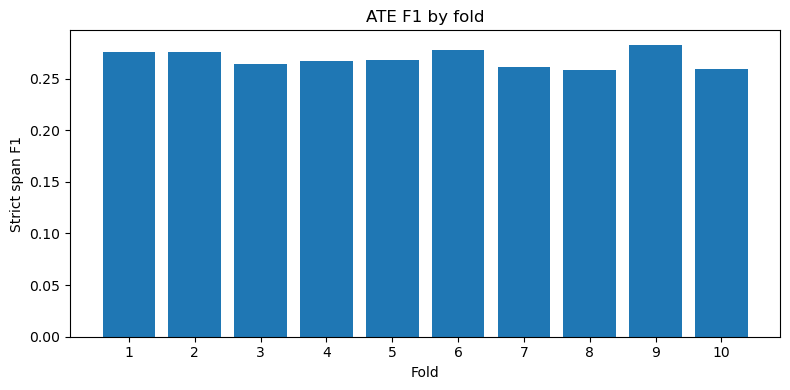

In [16]:
folds = pd.DataFrame(package["folds"])
display(folds[["fold", "ate_precision", "ate_recall", "ate_f1", "ate_threshold"]])
print("ATE mean F1:", package["aggregate"]["ate_f1_mean"], "±", package["aggregate"]["ate_f1_std"])

plt.figure(figsize=(8, 4))
plt.bar(folds["fold"].astype(str), folds["ate_f1"])
plt.xlabel("Fold")
plt.ylabel("Strict span F1")
plt.title("ATE F1 by fold")
plt.tight_layout()
plt.show()

## 5. ACD and implicit-aspect detection

In [17]:
print("ACD pooled:", package["acd"]["pooled"]["micro_f1"], package["acd"]["pooled"]["macro_f1"])
display(pd.DataFrame(package["acd"]["pooled"]["per_class"]).T.sort_values("f1", ascending=False))

print("\nImplicit detection pooled:", package["implicit_detection"]["pooled"]["micro_f1"], package["implicit_detection"]["pooled"]["macro_f1"])
display(pd.DataFrame(package["implicit_detection"]["pooled"]["per_class"]).T.sort_values("f1", ascending=False))

ACD pooled: 0.6828500786693639 0.6218227823437726


,precision,recall,f1,support
Baterija,0.723881,0.875056,0.792322,2217.0
Opšta ocena,0.713799,0.808100,0.758028,3111.0
Kamera,0.630494,0.802486,0.706168,1448.0
Softver,0.681841,0.692827,0.687291,1924.0
Hardver,0.686461,0.614023,0.648224,1412.0
Cena,0.534173,0.674234,0.596086,881.0
Zvučnici,0.660333,0.540856,0.594652,514.0
Ekran,0.563315,0.618609,0.589669,978.0
Izgled,0.519196,0.658933,0.580777,862.0
Performanse,0.530094,0.611204,0.567767,1196.0



Implicit detection pooled: 0.340140499918314 0.20840273944251878


,precision,recall,f1,support
Hardver,0.583333,0.402985,0.476671,469.0
Performanse,0.460772,0.442584,0.451495,836.0
Izgled,0.372093,0.332468,0.351166,385.0
Cena,0.309783,0.275362,0.291560,207.0
Opšta ocena,0.294723,0.229920,0.258319,996.0
Baterija,0.242424,0.172662,0.201681,139.0
Softver,0.242775,0.148936,0.184615,282.0
Zvučnici,0.200000,0.047619,0.076923,42.0
Kamera,0.000000,0.000000,0.000000,25.0
Ekran,0.000000,0.000000,0.000000,22.0


## 6. Oracle and chained diagnostics (not end-to-end)

These results diagnose individual pipeline stages. They use gold aspects, and the oracle sentiment evaluation also uses the gold category, so they are not directly comparable with the end-to-end result.

In [18]:
print("Oracle category:", package["oracle_category"]["aggregate"])
print(package["oracle_category"]["classification_report"])
print("Oracle sentiment:", package["oracle_sentiment"]["aggregate"])
print(package["oracle_sentiment"]["classification_report"])
print("Chained sentiment:", package["chained_sentiment"]["aggregate"])
print(package["chained_sentiment"]["classification_report"])

Oracle category: {'pooled_accuracy': 0.5168945884105784, 'pooled_macro_f1': 0.4616300456886407}
              precision    recall  f1-score   support

    Baterija     0.5450    0.7445    0.6293      2716
      Kamera     0.7129    0.4729    0.5686      2248
       Ekran     0.6998    0.3141    0.4336      1232
    Memorija     0.6250    0.2368    0.3435       190
    Zvučnici     0.6799    0.2834    0.4000       667
      Izgled     0.4915    0.2773    0.3546      1143
     Hardver     0.5843    0.4202    0.4888      1766
     Softver     0.6267    0.5840    0.6046      2774
 Performanse     0.3565    0.2113    0.2654      1358
        Cena     0.4978    0.4672    0.4820       976
 Opšta ocena     0.3998    0.6946    0.5075      3723

    accuracy                         0.5169     18793
   macro avg     0.5654    0.4278    0.4616     18793
weighted avg     0.5485    0.5169    0.5066     18793

Oracle sentiment: {'pooled_accuracy': 0.7312297131910818, 'pooled_macro_f1': 0.411833699935

## 7. End-to-end ACSA evaluation on raw text

This is the final evaluation of the complete pipeline: aspects and categories are predicted from text first, followed by sentiment. Unlike the oracle diagnostics, this evaluation does not use gold aspect or category labels.

End-to-end pooled tuple F1: {'precision': 0.5695897865215571, 'recall': 0.3552176466749331, 'f1': 0.4375577796535231, 'tp': 5443, 'fp': 4113, 'fn': 9880}
Exact set-match rate: 0.1808641975308642


,fold,e2e_pair_precision,e2e_pair_recall,e2e_pair_f1
0,1,0.563918,0.374658,0.450206
1,2,0.587673,0.372893,0.456271
2,3,0.578610,0.345687,0.432800
3,4,0.571287,0.377124,0.454331
4,5,0.590129,0.351662,0.440705
5,6,0.534103,0.325240,0.404289
6,7,0.563484,0.356574,0.436763
7,8,0.597497,0.365201,0.453323
8,9,0.557692,0.349841,0.429965
9,10,0.551913,0.335325,0.417183


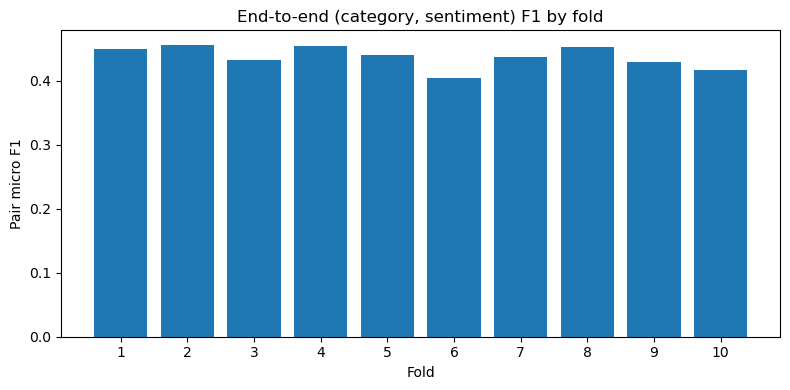

In [19]:
print("End-to-end pooled tuple F1:", package["end_to_end"]["pooled"])
print("Exact set-match rate:", package["end_to_end"]["set_exact_match_rate"])
display(folds[["fold", "e2e_pair_precision", "e2e_pair_recall", "e2e_pair_f1"]])

plt.figure(figsize=(8, 4))
plt.bar(folds["fold"].astype(str), folds["e2e_pair_f1"])
plt.xlabel("Fold")
plt.ylabel("Pair micro F1")
plt.title("End-to-end (category, sentiment) F1 by fold")
plt.tight_layout()
plt.show()

## 8. Error examples

In [20]:
import json

err_path = RESULTS_DIR / "error_examples.json"
errors = json.loads(err_path.read_text(encoding="utf-8"))
for i, ex in enumerate(errors[:10], 1):
    print(f"\n[{i}] comment_id={ex['comment_id']}")
    print(" true:", ex["true_pairs"])
    print(" pred:", ex["pred_pairs"])


[1] comment_id=2
 true: ['Izgled|||Pozitivan']
 pred: []

[2] comment_id=52
 true: ['Cena|||Negativan']
 pred: ['Cena|||Negativan', 'Opšta ocena|||Pozitivan']

[3] comment_id=76
 true: ['Softver|||Negativan']
 pred: ['Baterija|||Negativan']

[4] comment_id=102
 true: ['Cena|||Negativan']
 pred: ['Cena|||Negativan', 'Kamera|||Neutralan']

[5] comment_id=227
 true: ['Opšta ocena|||Pozitivan', 'Softver|||Pozitivan']
 pred: ['Opšta ocena|||Negativan', 'Softver|||Negativan']

[6] comment_id=283
 true: ['Hardver|||Negativan']
 pred: ['Cena|||Pozitivan', 'Izgled|||Pozitivan', 'Opšta ocena|||Pozitivan']

[7] comment_id=291
 true: ['Baterija|||Pozitivan']
 pred: ['Baterija|||Negativan', 'Performanse|||Negativan']

[8] comment_id=335
 true: ['Baterija|||Negativan']
 pred: ['Baterija|||Pozitivan']

[9] comment_id=343
 true: ['Cena|||Negativan', 'Kamera|||Pozitivan', 'Opšta ocena|||Negativan']
 pred: ['Cena|||Pozitivan', 'Opšta ocena|||Pozitivan']

[10] comment_id=393
 true: ['Cena|||Negativan', 

## 9. Saved results

- `results/naive_bayes_full/metrics.json`
- `results/naive_bayes_full/folds.csv`
- `results/naive_bayes_full/ate_predictions.csv`
- `results/naive_bayes_full/e2e_pair_predictions.csv`

### Additional F1 metrics

The code below reports additional averaging variants for the end-to-end F1 score from the saved predictions.

### Computational cost and execution environment

Multinomial Naive Bayes is a classical probabilistic model with no neural layers. Therefore, average time per layer and neural-network-style total/trainable parameter counts are not applicable. The learned statistical quantities are the class log-priors and feature log-probabilities, and their number depends on vocabulary size $V$. For a $K$-class NB model, the total number of learned values is $K V + K$. All of these statistical values are fitted from data, but calling them trainable parameters is not directly comparable to neural-network parameters. For One-vs-Rest multilabel models, the total is the sum across the fitted binary estimators.

| Component | Classes/model structure | Learned-value formula | Exact count |
|---|---:|---:|---|
| ATE binary NB | $K=2$ | $2V + 2$ | Unavailable: fitted estimator and vocabulary size were not persisted |
| Category NB | $K=11$ | $11V + 11$ | Unavailable: fitted estimator and vocabulary size were not persisted |
| Sentiment NB | $K=4$ | $4V + 4$ | Unavailable: fitted estimator and vocabulary size were not persisted |
| ACD / implicit One-vs-Rest | Sum over fitted binary models | $\sum_j (2V_j + 2)$ | Unavailable: fitted estimators and vocabulary sizes were not persisted |

The latest measured runtime used resume mode and reused fold 1, so it is not a clean from-scratch benchmark. The code reports this run separately from the earlier clean, non-resumed 10-fold run and labels per-fold timing as an execution average, not per-layer time. Selected settings are reported as hyperparameters, not trainable parameters.

In [21]:
# Additional F1 metrics for the end-to-end evaluation
import ast
import json
import platform
import sys
from pathlib import Path

import pandas as pd
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer

here = Path.cwd()
repo_root = here if (here / "results" / "naive_bayes_full").exists() else here.parent
results_dir = repo_root / "results" / "naive_bayes_full"
predictions_path = results_dir / "e2e_pair_predictions.csv"
metrics_path = results_dir / "metrics.json"

with metrics_path.open(encoding="utf-8") as handle:
    package = json.load(handle)

predictions = pd.read_csv(predictions_path)
true_pairs = predictions["true_pairs"].map(ast.literal_eval)
predicted_pairs = predictions["pred_pairs"].map(ast.literal_eval)
labels = sorted(set().union(*(map(set, true_pairs)), *(map(set, predicted_pairs))))

mlb = MultiLabelBinarizer(classes=labels)
y_true = mlb.fit_transform(true_pairs)
y_pred = mlb.transform(predicted_pairs)

end_to_end_f1 = pd.Series({
    "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "samples_f1": f1_score(y_true, y_pred, average="samples", zero_division=0),
})
display(end_to_end_f1.to_frame("score"))

# Computational cost and execution environment; this uses existing results only.
runtime_seconds = float(package["runtime_seconds"])
n_outer = int(package["config"]["n_outer"])
resume_enabled = bool(package["config"].get("resume", False))
library_versions = package.get("library_versions", {})

execution_report = pd.DataFrame([
    ("Latest measured experiment wall-clock time", f"{runtime_seconds:.6f} s"),
    ("Number of outer folds", n_outer),
    ("Latest execution average per outer fold (not per-layer time)", f"{runtime_seconds / n_outer:.6f} s"),
    ("Resume enabled for latest run", resume_enabled),
    ("Latest-run benchmark note", "Reused fold 1; not a clean from-scratch training benchmark"),
    ("Earlier clean non-resumed 10-fold wall-clock time", "6307.459787130356 s"),
    ("Earlier clean execution average per fold", "630.7459787130356 s"),
    ("Hardware", "Apple M4 CPU; 10 cores (4 performance + 6 efficiency); 16 GB unified memory"),
    ("Execution mode", "CPU-only scikit-learn execution"),
    ("Parallelism", "N_JOBS=-1 uses all available CPU cores"),
    ("Python", sys.version.split()[0]),
    ("Platform", f"{platform.system()} {platform.release()} ({platform.machine()})"),
    ("scikit-learn", library_versions.get("sklearn", "unavailable")),
    ("pandas", library_versions.get("pandas", "unavailable")),
    ("NumPy", library_versions.get("numpy", "unavailable")),
], columns=["Item", "Value"])
display(execution_report)

# Selected hyperparameters are configuration choices, not trainable parameters.
hyperparameter_rows = []
for component, selections in package.get("chosen_params", {}).items():
    for selection in selections:
        params = selection.get("params", {})
        hyperparameter_rows.append({
            "component": component,
            "fold": selection.get("fold"),
            "hyperparameters": ", ".join(
                f"{name}={value}" for name, value in sorted(params.items())
            ) if params else "No fitted estimator / no selected values",
        })

selected_hyperparameters = pd.DataFrame(
    hyperparameter_rows,
    columns=["component", "fold", "hyperparameters"],
).sort_values(["component", "fold"], ignore_index=True)
display(selected_hyperparameters)

,score
micro_f1,0.437558
weighted_f1,0.422823
macro_f1,0.204949
samples_f1,0.420217


,Item,Value
0,Latest measured experiment wall-clock time,4.102346 s
1,Number of outer folds,10
2,Latest execution average per outer fold (not p...,0.410235 s
3,Resume enabled for latest run,True
4,Latest-run benchmark note,Reused fold 1; not a clean from-scratch traini...
5,Earlier clean non-resumed 10-fold wall-clock time,6307.459787130356 s
6,Earlier clean execution average per fold,630.7459787130356 s
7,Hardware,Apple M4 CPU; 10 cores (4 performance + 6 effi...
8,Execution mode,CPU-only scikit-learn execution
9,Parallelism,N_JOBS=-1 uses all available CPU cores


,component,fold,hyperparameters
0,acd,1,"clf__estimator__alpha=0.5, clf__estimator__fit..."
1,acd,2,"clf__estimator__alpha=0.5, clf__estimator__fit..."
2,acd,3,"clf__estimator__alpha=0.5, clf__estimator__fit..."
3,acd,4,"clf__estimator__alpha=0.5, clf__estimator__fit..."
4,acd,5,"clf__estimator__alpha=0.5, clf__estimator__fit..."
5,acd,6,"clf__estimator__alpha=0.5, clf__estimator__fit..."
6,acd,7,"clf__estimator__alpha=0.5, clf__estimator__fit..."
7,acd,8,"clf__estimator__alpha=0.5, clf__estimator__fit..."
8,acd,9,"clf__estimator__alpha=0.5, clf__estimator__fit..."
9,acd,10,"clf__estimator__alpha=0.5, clf__estimator__fit..."
